In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from collections import defaultdict
from scipy import stats
from pathlib import Path

#### Specify the time periods.

In [4]:
discharge_coverage_path = Path("~/BA/data/processed_data/eda/discharge_coverage.pkl")

discharge_coverage = pd.read_pickle(discharge_coverage_path)

##### Visualize normal periods for a subsample of basins. 

Basin 55 is the odd one out, it shows systematic gaps, and is therefore not usable.

In [5]:
min_normal_len = 1 

In [6]:
#fig, ax = plt.subplots(figsize=(10, len(discharge_coverage) * 0.25))

yticks = []
yticklabels = []

# Test pickling. 
train_dict = defaultdict(dict)
val_dict = defaultdict(dict)
test_dict = defaultdict(dict)

for basin in discharge_coverage.itertuples():

    basin_dict = {
        "start_dates": [],
        "end_dates" : []
    }
    normal_periods = []

    for period in basin[-2]: 

        x_min = period[0]
        x_width = (period[1] - period[0])

        if x_width.days > min_normal_len: 
            normal_periods.append((x_min,x_width))

            # Attach for pickling. 
            basin_dict["start_dates"].append(period[0])
            basin_dict["end_dates"].append(period[1])

    #ax.broken_barh(xranges=normal_periods, yrange=(len(yticks), 0.5))

    basin_id = basin[0]

    if len(basin_dict["end_dates"]) != 0: 

        if basin_id < 600:
            train_dict[str(basin_id)] = basin_dict
        elif basin_id < 750: 
            val_dict[str(basin_id)] = basin_dict
        else: 
            test_dict[str(basin_id)] = basin_dict

    #yticks.append(len(yticks))
    #yticklabels.append(basin[0])

#ax.set_yticks(yticks)
#ax.set_yticklabels(yticklabels)
#ax.set_ylim(-1,len(yticks)+1)
#
#plt.tight_layout()
#plt.show()


In [7]:
n_samples = 0

for basin in discharge_coverage["q5_q95_normal_periods"]: 

    for period in basin: 

        duration = (period[1] - period[0]).days

        if duration >= min_normal_len:
            n_samples += duration

print(n_samples)

9391290


#### Specify the basin IDs.

In [8]:
# Remove NA & non-numeric columns and normalize with z-score for PCA.

scaler = preprocessing.StandardScaler()

# Load attributes and hydrologic indices.
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

# Drop Na and non-numeric columns, to prep for clustering.
no_na_attributes = basin_stca_gdf.dropna().sort_index()
numeric_attributes = no_na_attributes.select_dtypes(include=["number"])
scaled_attributes = pd.DataFrame(
    scaler.fit_transform(numeric_attributes.values),
    columns=numeric_attributes.columns,
    index=numeric_attributes.index
)

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
    scaler.fit_transform(numeric_hy_id.values),
    columns=numeric_hy_id.columns,
    index=numeric_hy_id.index
)

# Remove basins for which no hy_id exists. 
common_ids = scaled_attributes.index.intersection(scaled_hy_id.index)
scaled_attributes = scaled_attributes.loc[common_ids]
scaled_hy_id = scaled_hy_id.loc[common_ids]

In [9]:
# Apply PCA to minimise cocorrelation.

pca = PCA(n_components=0.9, svd_solver="full")
pca_attributes = pca.fit_transform(scaled_attributes)
pca_hy_id = pca.fit_transform(scaled_hy_id)


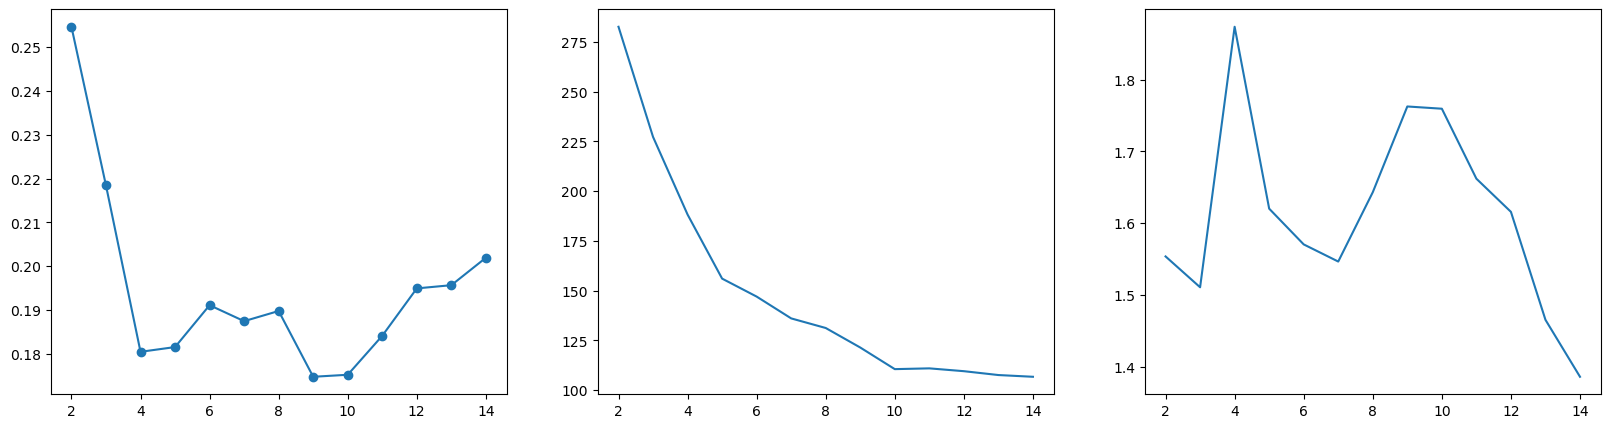

In [8]:
s_scores = []
CH_scores = []
DB_scores = []

aic_scores = []
bic_scores = []

for k in range(2,15):

    # Test for k-means.
    labels = KMeans(k,random_state=42).fit_predict(pca_attributes)
    s_scores.append(silhouette_score(pca_attributes,labels))
    CH_scores.append(calinski_harabasz_score(pca_attributes,labels))
    DB_scores.append(davies_bouldin_score(pca_attributes, labels))

    # Test for gmm.
    gmm = GaussianMixture(k, random_state=42)
    gmm.fit(pca_attributes)
    aic_scores.append(gmm.aic(pca_attributes))
    bic_scores.append(gmm.bic(pca_attributes))

fig, axs = plt.subplots(1,3, figsize=(20,5))

axs[0].plot(range(2,15), s_scores, marker="o")
axs[1].plot(range(2,15), CH_scores)
axs[2].plot(range(2,15), DB_scores)

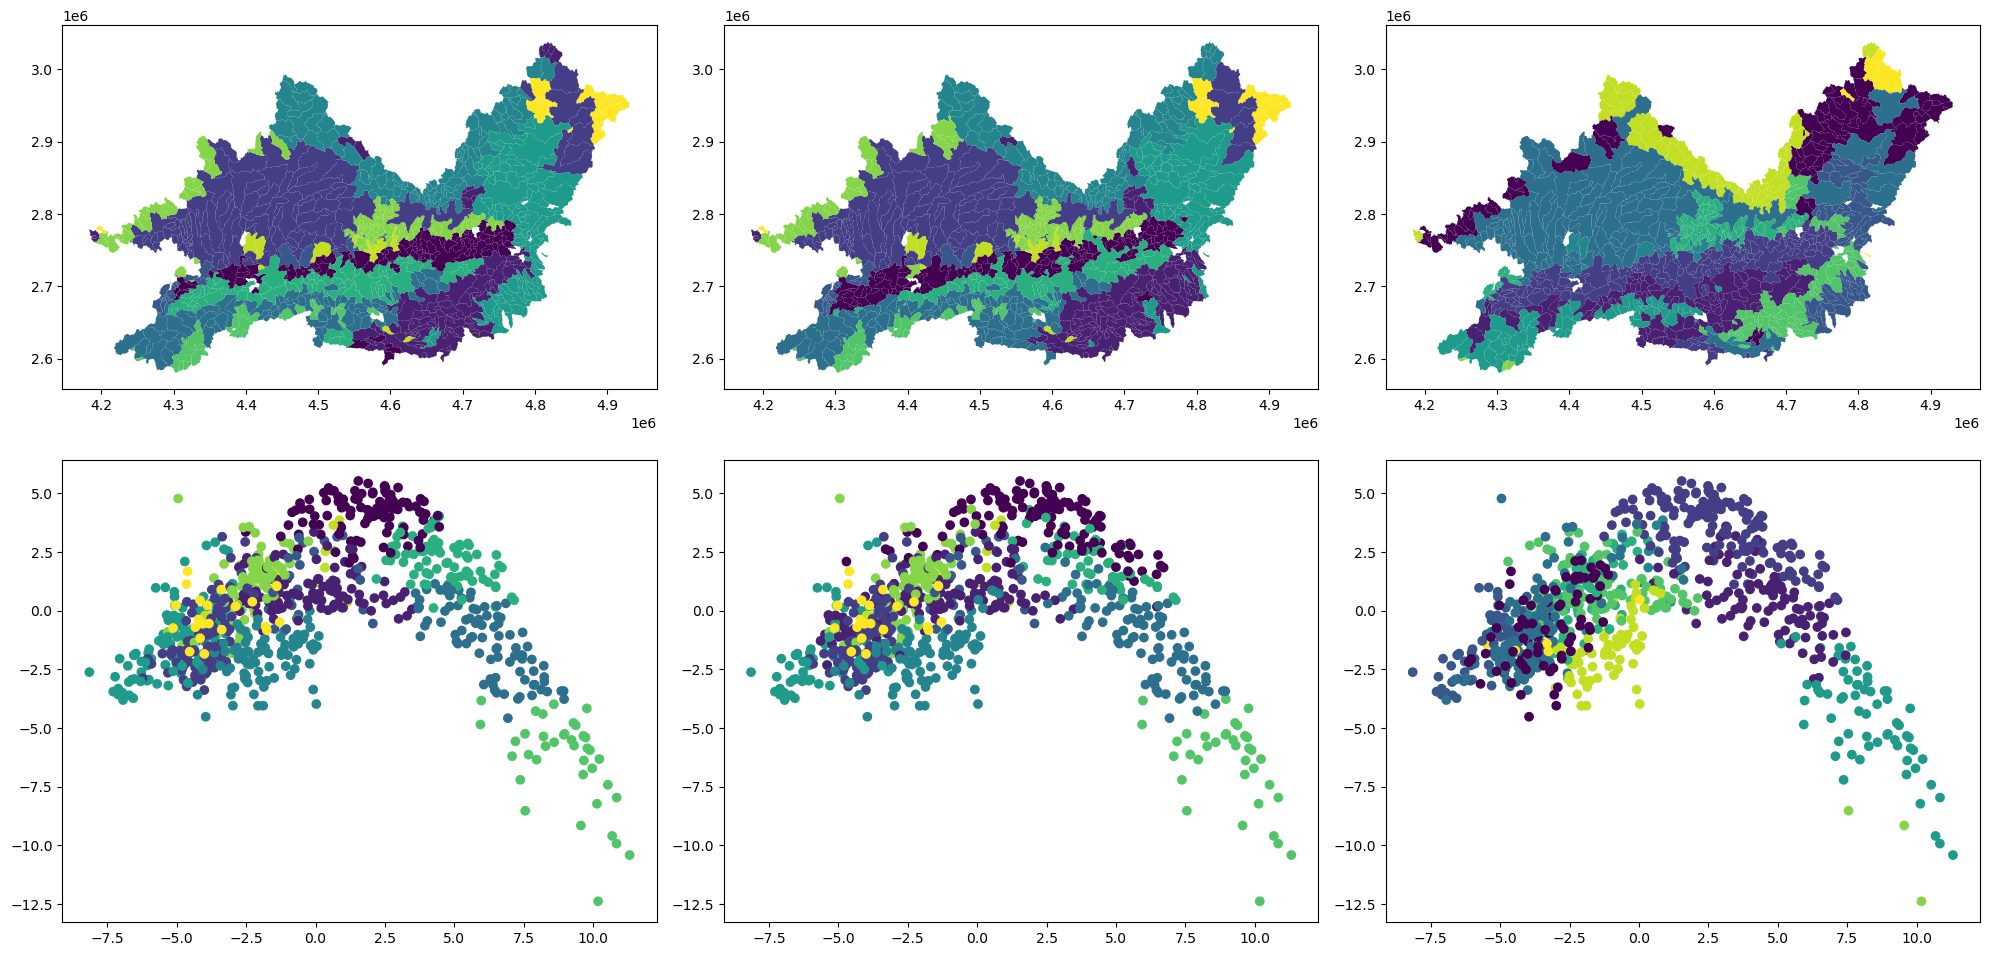

In [34]:
n_clusters = 12

# CLUSTER
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(pca_attributes)
kmeans_labels = pd.Series(kmeans.labels_,scaled_attributes.index)

gmm = GaussianMixture(n_components=n_clusters,random_state=42)
gmm_labels = pd.Series(gmm.fit_predict(pca_attributes), scaled_attributes.index)

agglo = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = pd.Series(agglo.fit_predict(pca_attributes), scaled_attributes.index)

# PLOT
plot_gdf = no_na_attributes.copy()
plot_gdf["kmeans_labels"] = kmeans_labels
plot_gdf["gmm_labels"] = gmm_labels
plot_gdf["agglo_labels"] = agglo_labels

# Assign one fix color for each cluster
cmap = mpl.colormaps["viridis"].resampled(n_clusters)
vmin = plot_gdf["kmeans_labels"].min()
vmax = plot_gdf["kmeans_labels"].max()

fig, axs = plt.subplots(2,3,figsize=(20,10))

plot_gdf.plot(
    ax=axs[0,0],
    column="kmeans_labels",
    cmap=cmap, vmin=vmin, vmax=vmax
)

plot_gdf.plot(
    ax=axs[0,1],
    column="gmm_labels",
    cmap=cmap, vmin=vmin, vmax=vmax)

plot_gdf.plot(
    ax=axs[0,2],
    column="agglo_labels",
    cmap=cmap, vmin=vmin, vmax=vmax)

axs[1,0].scatter(pca_attributes[:,0], pca_attributes[:,1], c=kmeans_labels)
axs[1,1].scatter(pca_attributes[:,0], pca_attributes[:,1], c=gmm_labels)
axs[1,2].scatter(pca_attributes[:,0], pca_attributes[:,1], c=agglo_labels)

# Calculate mean values of hydro id per cluster group.
hy_id_mean_df = scaled_hy_id.groupby(kmeans_labels).mean()

#sns.heatmap(ax=axs[1,1],data=hy_id_mean_df.transpose())

plt.tight_layout()

In [12]:
#Check that the hy_id in each cluster are normally distributed. 

shapiro_test_results = []
var_test_results = []

for hy_id in scaled_hy_id.columns:

    groups = [scaled_hy_id.loc[kmeans_labels == cluster, hy_id] for cluster in kmeans_labels]

    var_test_results.append(stats.levene(*groups))

    for cluster in kmeans_labels.unique():

        shapiro_test_results.append(stats.shapiro(scaled_hy_id.loc[kmeans_labels == cluster, hy_id]))

# hy_id in the cluster are not normally distributed as well as not equal variance.


/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
#Create ANOVA for every hydro indices,

kruskal_results = {}

for hy_id in scaled_hy_id.columns:

    groups = [scaled_hy_id.loc[kmeans_labels == c, hy_id] for c in kmeans_labels.unique()]

    f_stat, p_val = stats.kruskal(*groups)

    kruskal_results[hy_id] = {"f": f_stat, "p": p_val}

kruskal_results

{'q_mean': {'f': 516.6817750999687, 'p': 2.0753506396847694e-107},
 'runoff_ratio': {'f': 446.10973435493247, 'p': 3.0396810497735295e-92},
 'stream_elas': {'f': 85.60864354330785, 'p': 9.839268259928217e-16},
 'slope_fdc': {'f': 256.5391744270011, 'p': 1.1231548213870241e-51},
 'baseflow_index_ladson': {'f': 127.21818361340961,
  'p': 2.3948390935053793e-24},
 'baseflow_index_lfstat': {'f': 126.89015295245197,
  'p': 2.803809875199868e-24},
 'hfd_mean': {'f': 543.7416535818302, 'p': 3.135650443135848e-113},
 'Q5': {'f': 400.57069142118206, 'p': 1.799508362267669e-82},
 'Q95': {'f': 513.2328774730449, 'p': 1.1448977421010458e-106},
 'high_q_freq': {'f': 211.49744578791066, 'p': 4.200639056014569e-42},
 'high_q_dur': {'f': 192.82412566991434, 'p': 3.791533188498512e-38},
 'low_q_freq': {'f': 154.25655389499133, 'p': 5.178372398914739e-30},
 'low_q_dur': {'f': 148.19849054000196, 'p': 9.699835814693172e-29},
 'zero_q_freq': {'f': 24.436569418309187, 'p': 0.0009544988357596196}}

Export time periods as .pkl and basin id splits as .txt.

In [14]:
import pickle as pkl

splits_directory_path = Path("/home/wuhlmann/BA/data/processed_data/test_splits")

with open(splits_directory_path / "train.pkl", "wb") as out: 
    pkl.dump(train_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "val.pkl", "wb") as out: 
    pkl.dump(val_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "test.pkl", "wb") as out: 
    pkl.dump(test_dict, out, protocol=pkl.HIGHEST_PROTOCOL)


In [15]:
with open(splits_directory_path / "train_basin_ids.txt", "w") as f: 
    for id in train_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "val_basin_ids.txt", "w") as f: 
    for id in val_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "test_basin_ids.txt", "w") as f: 
    for id in test_dict.keys():
        f.write(f"{id}\n")